# 5 — Tuning and explanation, under the protocol this repository replaced

**Read the box before the numbers.** This notebook and notebook 04 are the historical step: one
90/10 split, a threshold read off the test set, and every figure quoted from 147 rows of which
24 are departures. `docs/protocol.md` says what was wrong with that and what each correction was
worth — the short version is that the threshold was chosen on the data that then measured it,
and that the split was a favourable draw the repository under-read.

They are kept, executed, because the reasoning is the work: a grid search, a comparison of two
families, and a local explanation of one decision are all things this protocol does correctly
even when the split around them does not. Nothing under `reports/` comes out of this notebook.

What it does, in order: optimise the hyper-parameters of the two candidate families, pick one,
read the global importances, and explain two named individuals.

In [1]:
import mlflow
import mlflow.sklearn

# The store lives under `var/`, the one directory this repository ignores. It used to be
# `../mlruns`, which is outside the repository altogether: running this notebook wrote a
# nineteen-megabyte directory into the folder that holds the repository.
#
# `max_tuning_runs=1` keeps a grid search from writing one run per candidate, and
# `log_models=False` keeps it from writing the fitted estimator each time. Without both,
# a thirty-five-fit search leaves a few hundred megabytes behind and takes minutes to do it.
mlflow.set_tracking_uri("file:var/mlflow")
mlflow.set_experiment("attrition_serving_grid_search")
mlflow.sklearn.autolog(log_models=False, max_tuning_runs=1)


C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)


## Which metric the search optimises

Average precision, and not accuracy or ROC AUC.

On a problem with a 16 % base rate, accuracy rewards a model that never predicts a departure.
ROC AUC is insensitive to the imbalance but also to where the alert list stops, and the list is
the product. Average precision reads the precision-recall curve, which is the curve an HR team
lives on: it says what share of a list of a given length really leaves.

In [2]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split

from attrition_serving.config import PATHS, SETTINGS
from attrition_serving.modeling.evaluation import (
    evaluate_classifier,
    find_threshold_for_recall,
    plot_precision_recall,
)
from attrition_serving.modeling.models import make_logreg, make_random_forest
from attrition_serving.modeling.tuning import run_grid_search, summarize_grid_search
from attrition_serving.preprocessing import FeatureGroups

df = pd.read_parquet(PATHS.data_processed / "employees_features.parquet")

TARGET = "a_quitte_l_entreprise"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SETTINGS.random_state,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SETTINGS.random_state)
y.value_counts(normalize=True).round(3)

a_quitte_l_entreprise
0    0.839
1    0.161
Name: proportion, dtype: float64

In [3]:
# === Numériques ===
num_cont = [
    "age",
    "augmentation_salaire_precedente",
    "distance_domicile_travail",
    "proba_chgt_experience_par_an",
    "proba_chgt_experience_par_an_adulte",
    "ratio_experience_vie_adulte",
]

num_log = [
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annes_sous_responsable_actuel",
    "annees_depuis_la_derniere_promotion",
]

num_disc = [
    "nombre_participation_pee",
    "nb_formations_suivies",
    "nombre_employee_sous_responsabilite",
    "nombre_experiences_precedentes",
    "nombre_experiences_precedents",
]

# === Binaires ===
bin_cols = ["genre", "heure_supplementaires", "changement_poste"]

# === Nominales ===
cat_nom = ["statut_marital", "departement", "poste", "domaine_etude"]

# === Ordinales ===
cat_ord = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "niveau_hierarchique_poste",
    "niveau_education",
    "frequence_deplacement",
    "evolution_note",
]


# Only the columns the frame actually holds: the schema changed twice during the project,
# and a grouping that names an absent column fails inside the pipeline, not here.
def keep_existing(cols):
    return [c for c in cols if c in X.columns]


num_cont = keep_existing(num_cont)
num_log = keep_existing(num_log)
num_disc = keep_existing(num_disc)
bin_cols = keep_existing(bin_cols)
cat_nom = keep_existing(cat_nom)
cat_ord = keep_existing(cat_ord)

# Ordered categories keep their sorted order. A business order would have to come from the
# survey's own scale, and this dataset does not publish one.
ord_categories = [sorted(df[c].dropna().unique().tolist()) for c in cat_ord]

groups = FeatureGroups(
    num_cont=num_cont,
    num_log=num_log,
    num_disc=num_disc,
    bin_cols=bin_cols,
    cat_nom=cat_nom,
    cat_ord=cat_ord,
    ord_categories=ord_categories,
)

groups

FeatureGroups(num_cont=['age', 'distance_domicile_travail', 'proba_chgt_experience_par_an', 'proba_chgt_experience_par_an_adulte', 'ratio_experience_vie_adulte'], num_log=['revenu_mensuel', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'annes_sous_responsable_actuel', 'annees_depuis_la_derniere_promotion'], num_disc=['nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'nombre_experiences_precedentes'], bin_cols=['genre', 'heure_supplementaires', 'changement_poste'], cat_nom=['statut_marital', 'departement', 'poste', 'domaine_etude'], cat_ord=['satisfaction_employee_environnement', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_precedente', 'note_evaluation_actuelle', 'niveau_hierarchique_poste', 'niveau_education', 'frequence_deplacement', 'evolution_note'], ord_categories=[[1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2,

## The hyper-parameter search

A small grid, on purpose. With 1 470 rows and a fold-to-fold spread of about 0.058 on average
precision, a wide search finds differences it cannot distinguish from the draw, and every one of
them looks like a result.

The search runs inside a stratified cross-validation, and the preprocessing is inside the
pipeline: fitting a scaler or an encoder before the split would let the validation fold's
distribution reach the model that scores it.

In [4]:
logreg_pipe = make_logreg(groups)

# Three values of one parameter. `penalty` is not searched: scikit-learn 1.8 deprecates
# it in favour of `l1_ratio`, and the ridge the repository ships is `l1_ratio=0`.
param_grid_logreg = {"model__C": [0.01, 0.1, 1.0]}

gs_logreg = run_grid_search(
    pipeline=logreg_pipe,
    param_grid=param_grid_logreg,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
)

summary_logreg = summarize_grid_search(gs_logreg)
summary_logreg.head(10)

2026/09/15 12:00:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6de7fe6c69264a40988e8b00932d73a6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/15 12:00:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 5 folds for each of 3 candidates, totalling 15 fits


2026/09/15 12:00:55 INFO mlflow.sklearn.utils: Logging the best run, 2 runs will be omitted.


2026/09/15 12:00:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
1,1,0.639470,0.020299,0.683176,0.012144,{'model__C': 0.1}
2,2,0.634665,0.028518,0.685308,0.010779,{'model__C': 1.0}
0,3,0.610746,0.025417,0.640788,0.013837,{'model__C': 0.01}


In [5]:
rf_pipe = make_random_forest(groups)

# Four combinations, not thirty-six. With a fold-to-fold spread near 0.058 on average
# precision, a wider grid separates candidates the data cannot separate.
param_grid_rf = {
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [1, 5],
}

gs_rf = run_grid_search(
    pipeline=rf_pipe,
    param_grid=param_grid_rf,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
)

summary_rf = summarize_grid_search(gs_rf)
summary_rf.head(10)

2026/09/15 12:02:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0b8e2fc259914a508893a4b60f66be1d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/15 12:02:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 5 folds for each of 4 candidates, totalling 20 fits


2026/09/15 12:02:15 INFO mlflow.sklearn.utils: Logging the best run, 3 runs will be omitted.


2026/09/15 12:02:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
0,1,0.559453,0.056448,1.000000,1.216188e-16,"{'model__max_depth': None, 'model__min_samples..."
3,2,0.553200,0.053031,0.928349,7.209880e-03,"{'model__max_depth': 10, 'model__min_samples_l..."
1,3,0.548289,0.053602,0.933929,8.168441e-03,"{'model__max_depth': None, 'model__min_samples..."
2,4,0.544164,0.053959,0.999991,1.719986e-05,"{'model__max_depth': 10, 'model__min_samples_l..."


## Reading the search

Three things decide, in this order: the mean validation score, its spread across folds, and
whether the winning parameters mean anything.

A model a little behind on the mean and steadier across folds is the better choice here, and so
is a linear model over a forest at equal score: this decision sends a manager to talk to a named
person, and a coefficient can be read out loud.

In [6]:
best_logreg = gs_logreg.best_estimator_
best_rf = gs_rf.best_estimator_

res_logreg = evaluate_classifier(best_logreg, X_train, y_train, X_test, y_test, threshold=0.5)
res_rf = evaluate_classifier(best_rf, X_train, y_train, X_test, y_test, threshold=0.5)

print("LogReg AP train:", res_logreg["train_ap"])
print("LogReg AP test:", res_logreg["test_ap"])
print("RF AP train:", res_rf["train_ap"])
print("RF AP test:", res_rf["test_ap"])
print("\nLogReg report:\n", res_logreg["test_report"])
print("\nRF report:\n", res_rf["test_report"])
print("\nLogReg confusion matrix:\n", res_logreg["test_cm"])
print("\nRF confusion matrix:\n", res_rf["test_cm"])

2026/09/15 12:03:32 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'dab2471588004ca783e6fd0c2a3e4651', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/15 12:03:33 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:04:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:04:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:04:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a547c1027d6c4da9952f447d55804fbd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/15 12:04:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:05:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:05:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


LogReg AP train: 0.6872609660686652
LogReg AP test: 0.5992370642841178
RF AP train: 1.0
RF AP test: 0.3704499055886323

LogReg report:
               precision    recall  f1-score   support

           0      0.926     0.806     0.861       247
           1      0.392     0.660     0.492        47

    accuracy                          0.782       294
   macro avg      0.659     0.733     0.677       294
weighted avg      0.840     0.782     0.802       294


RF report:
               precision    recall  f1-score   support

           0      0.850     0.964     0.903       247
           1      0.357     0.106     0.164        47

    accuracy                          0.827       294
   macro avg      0.604     0.535     0.534       294
weighted avg      0.771     0.827     0.785       294


LogReg confusion matrix:
 [[199  48]
 [ 16  31]]

RF confusion matrix:
 [[238   9]
 [ 42   5]]


## The final model, at an operating point

The hyper-parameters are frozen and the metrics are read at the threshold this step chose.

That threshold is the defect `docs/protocol.md` documents: `find_threshold_for_recall` reads it
off `y_test`, so the recall it reports is the definition of the threshold and not a property of
the model. The corrected version settles it before the scoring fold is opened, and publishes what the
difference between the two methods was worth.

2026/09/15 12:05:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


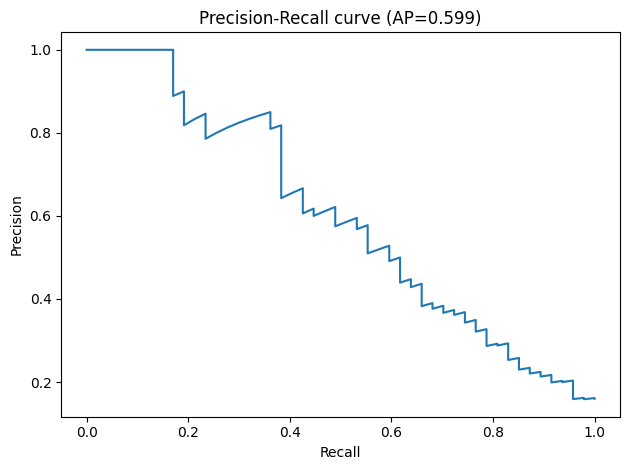

0.3753074304269573

In [7]:
final_model = best_logreg
p_test = final_model.predict_proba(X_test)[:, 1]

plot_precision_recall(y_test, p_test)

thr = find_threshold_for_recall(y_test, p_test, target_recall=0.80)
thr

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)

# `_cuts`, not `thr`: the cell above binds `thr` to the operating point, and rebinding
# it to the curve's whole array of cut points made the next cell compare a vector of
# 1 176 thresholds against 294 predictions.
precision, recall, _cuts = precision_recall_curve(y_test, p_test)
ap = average_precision_score(y_test, p_test)

plt.figure()
plt.plot(recall, precision)
plt.title(f"Precision-Recall curve (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")

Text(0, 0.5, 'Precision')

In [9]:
res_thr = evaluate_classifier(final_model, X_train, y_train, X_test, y_test, threshold=thr)
print(res_thr["test_report"])
print(res_thr["test_cm"])

2026/09/15 12:05:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0f11798aca1147eab90116758a7b457a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/09/15 12:05:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:06:38 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/09/15 12:06:38 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


              precision    recall  f1-score   support

           0      0.945     0.628     0.754       247
           1      0.292     0.809     0.429        47

    accuracy                          0.656       294
   macro avg      0.619     0.718     0.592       294
weighted avg      0.841     0.656     0.702       294

[[155  92]
 [  9  38]]


## Which columns the model leans on

Permutation importance: shuffle one column, and measure what the score loses. It answers "what
is this model using", and it answers it about the model rather than about the world.

`reports/permutation_importance.csv` carries the published version, measured inside the 25 folds
of the corrected protocol by `scripts/run_evaluation.py`. What follows is the same idea on this
notebook's single split, and the two are not the same measurement.

In [10]:
from attrition_serving.analysis.explainability import permutation_importance_df

perm_df = permutation_importance_df(
    final_model, X_test, y_test, scoring="average_precision", n_repeats=20
)
perm_df.head(20)

,feature,importance_mean,importance_std
18,heure_supplementaires,0.238905,0.029682
13,satisfaction_employee_nature_travail,0.074419,0.019293
29,annees_depuis_la_derniere_promotion,0.064808,0.020078
7,annee_experience_totale,0.064799,0.033973
10,satisfaction_employee_environnement,0.060408,0.026373
6,nombre_experiences_precedentes,0.043873,0.013244
2,revenu_mensuel,0.029177,0.018673
14,satisfaction_employee_equipe,0.020412,0.014286
1,genre,0.016280,0.007578
25,distance_domicile_travail,0.015065,0.016451


## The beeswarm, and how to read it

One point per employee, one row per column. The position on the x-axis is how much that column
moved that person's prediction; the colour is whether the value was high or low.

It shows three things at once: which columns matter, how spread their effect is, and in which
direction a high value pushes. A column whose points sit in a tight cluster at zero is a column
the model ignores, whatever its coefficient says.

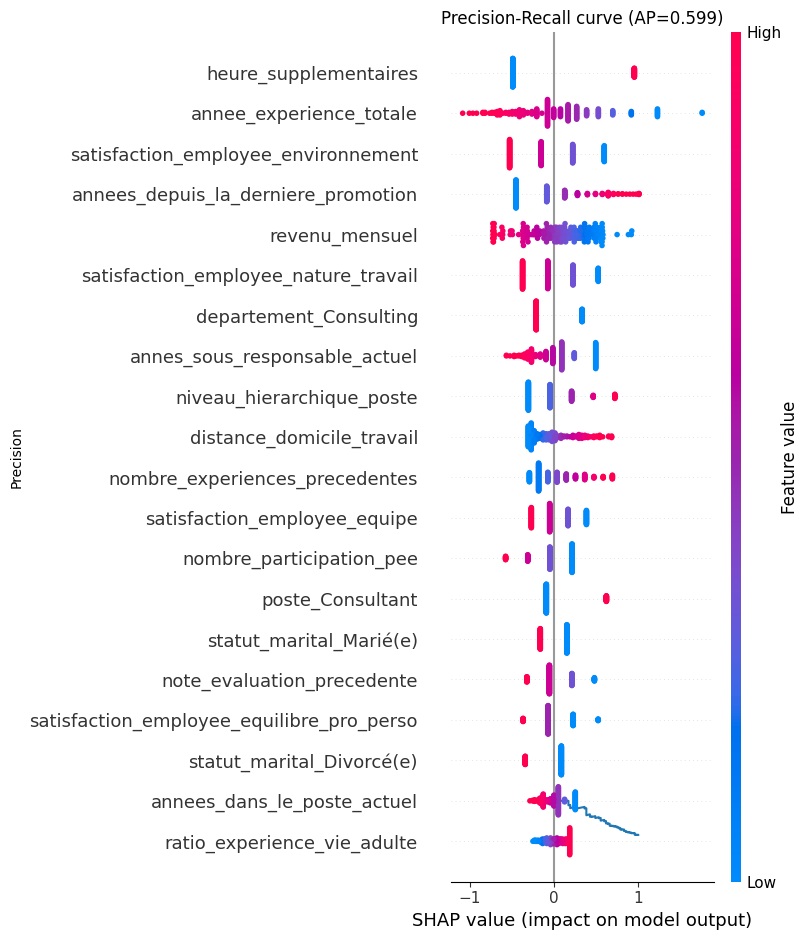

In [11]:
import shap

from attrition_serving.analysis.explainability import shap_explain_linear_model

# A small background sample: the explanation is stable enough at two hundred rows, and the
# cost of the linear explainer grows with it.
X_bg = X_train.sample(min(200, len(X_train)), random_state=SETTINGS.random_state)
X_exp = X_test.sample(min(200, len(X_test)), random_state=SETTINGS.random_state)

explainer, shap_values, X_exp_t, feature_names = shap_explain_linear_model(final_model, X_bg, X_exp)

# Global beeswarm
shap.summary_plot(shap_values, X_exp_t, feature_names=feature_names)

## One column, in detail

The dependence plot puts a column's value on the x-axis and its own contribution on the y-axis,
one point per employee.

It is where a non-linear effect shows: a straight line means the model treats the column
linearly, a bend means the effect changes with the level, and vertical spread at a single value
means another column is interacting with this one.

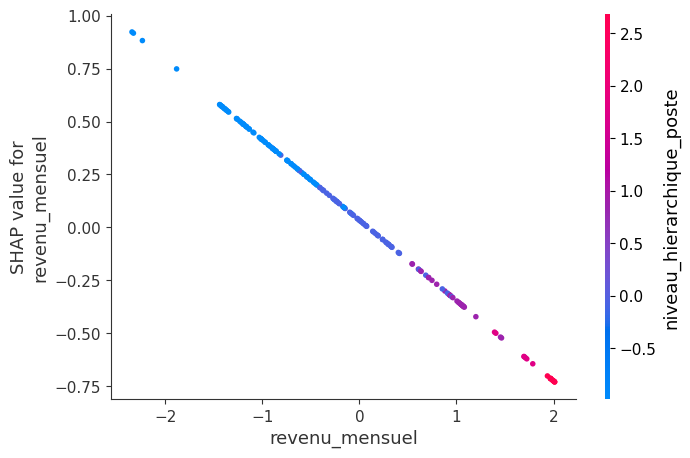

In [12]:
feature = "revenu_mensuel"

# The dependence plot
shap.dependence_plot(
    feature,
    shap_values,  # array (n_samples, n_features)
    X_exp_t,  # array des features transformées (n_samples, n_features)
    feature_names=feature_names,
    interaction_index="auto",  # or a column name, to force the interaction shown
)

## Explaining one decision

The question a manager asks is not "which columns matter" but "why this person".

Answering it is the difference between an alert somebody acts on and an alert somebody argues
with — and it is the reason this repository serves a linear model.

## Reading a waterfall

The plot starts at the model's average prediction and adds one bar per column: what that
column's value contributed for this individual, up or down, ending at the prediction returned.

Two people are shown, the highest and the lowest risk in the test split. Comparing them is what
makes the bars legible: the same columns appear, with opposite signs.

2026/09/15 12:06:39 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Ben\AppData\Local\uv-venvs\lab-attrition-serving-api\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


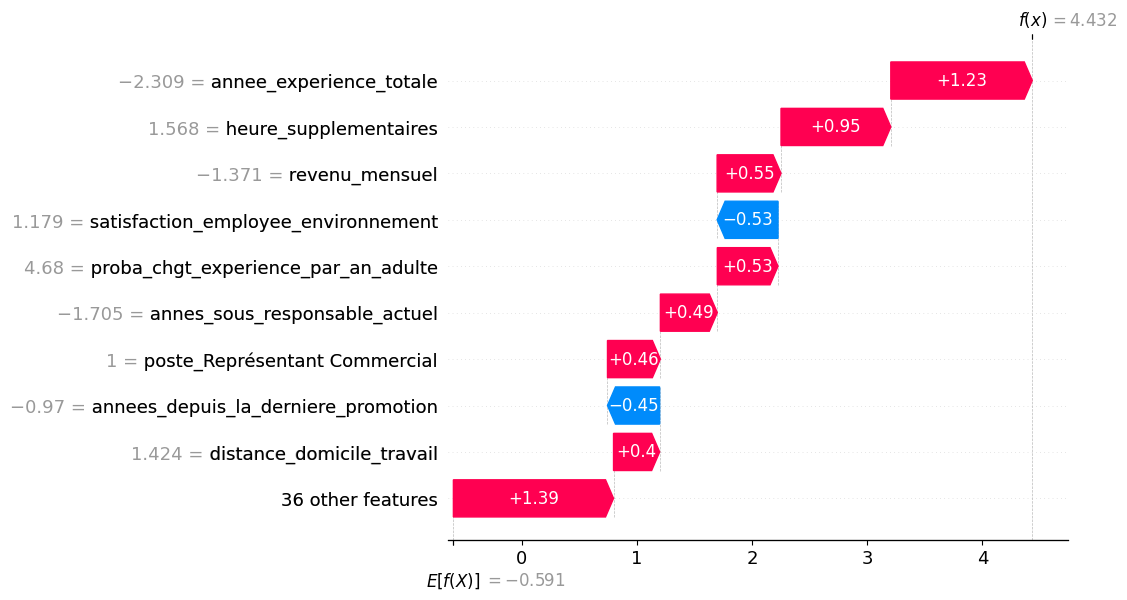

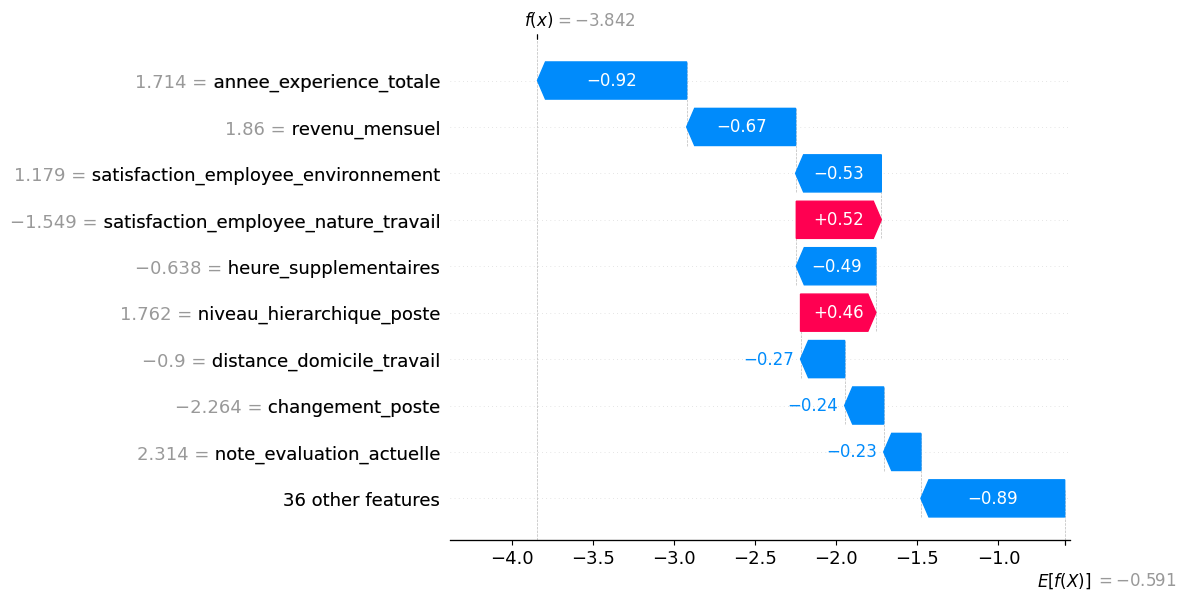

In [13]:
probas = final_model.predict_proba(X_test)[:, 1]
idx_high = probas.argmax()
idx_low = probas.argmin()

X_one_high = X_test.iloc[[idx_high]]
X_one_low = X_test.iloc[[idx_low]]

# Transform, then SHAP values, for one individual
Xb = X_bg
explainer, shap_vals_high, Xh_t, fn = shap_explain_linear_model(final_model, Xb, X_one_high)
explainer, shap_vals_low, Xl_t, fn = shap_explain_linear_model(final_model, Xb, X_one_low)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_high[0],
        base_values=explainer.expected_value,
        data=Xh_t[0],
        feature_names=fn,
    )
)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_low[0],
        base_values=explainer.expected_value,
        data=Xl_t[0],
        feature_names=fn,
    )
)

## What an explanation is not

SHAP explains the **model**, not the world. The relations it shows are the ones the model
learned, and the model learned them from a cross-section that cannot separate a cause from a
symptom.

A bias in the data is a bias in the explanation, shown with the same confidence as everything
else. `docs/protocol.md` carries the subgroup table, which is the closest this repository comes
to measuring one.

## What this notebook settled

A grid search that changed little, a linear model kept over a forest for readability at an equal
score, and a set of explanations that hold for the model as fitted here.

What it did not settle is any published number. Those come from `scripts/run_evaluation.py`,
under the protocol of `docs/protocol.md`, and notebook 06 reads them.